In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
data_path = "computer_prices_all.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
print(df.dtypes)

device_type                str
brand                      str
model                      str
release_year             int64
os                         str
form_factor                str
cpu_brand                  str
cpu_model                  str
cpu_tier                 int64
cpu_cores                int64
cpu_threads              int64
cpu_base_ghz           float64
cpu_boost_ghz          float64
gpu_brand                  str
gpu_model                  str
gpu_tier                 int64
vram_gb                  int64
ram_gb                   int64
storage_type               str
storage_gb               int64
storage_drive_count      int64
display_type               str
display_size_in        float64
resolution                 str
refresh_hz               int64
battery_wh               int64
charger_watts            int64
psu_watts                int64
wifi                       str
bluetooth              float64
weight_kg              float64
warranty_months          int64
price   

In [4]:
missing_values = df.isnull().sum()
missing_values

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

In [5]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [6]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

df_encoded = df.copy()

In [7]:
for col in df_encoded:
    print(f"{col}: {df[col].nunique()}")

device_type: 2
brand: 10
model: 99036
release_year: 8
os: 4
form_factor: 10
cpu_brand: 3
cpu_model: 26971
cpu_tier: 6
cpu_cores: 12
cpu_threads: 25
cpu_base_ghz: 8
cpu_boost_ghz: 18
gpu_brand: 4
gpu_model: 49
gpu_tier: 6
vram_gb: 8
ram_gb: 15
storage_type: 4
storage_gb: 5
storage_drive_count: 4
display_type: 6
display_size_in: 9
resolution: 6
refresh_hz: 6
battery_wh: 8
charger_watts: 7
psu_watts: 9
wifi: 4
bluetooth: 5
weight_kg: 47
warranty_months: 4
price: 3366


In [8]:
related_cols = ["model", "cpu_model", "gpu_model", "resolution", "wifi"]
unrelated_cols = ["device_type", "brand", "os", "form_factor", "cpu_brand", "gpu_brand", "storage_type", "display_type"]

In [9]:
print(f"Label Encoding columns: {len(related_cols)}")
print(related_cols)

print(f"OneHot Encoding columns: {len(unrelated_cols)}")
print(unrelated_cols)

#Label Encoding
label_encoder = LabelEncoder()

for col in related_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

#One-Hot Encoding
onehot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_data = onehot_encoder.fit_transform(df_encoded[unrelated_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=onehot_encoder.get_feature_names_out(unrelated_cols),
    index=df_encoded.index
)

df_encoded = df_encoded.drop(columns=unrelated_cols)

df_encoded = pd.concat(
    [df_encoded, encoded_df],
    axis=1
)

print(df_encoded.head())
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")

Label Encoding columns: 5
['model', 'cpu_model', 'gpu_model', 'resolution', 'wifi']
OneHot Encoding columns: 8
['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type']
   model  release_year  cpu_model  cpu_tier  cpu_cores  cpu_threads  \
0  94022          2022      17269         3         12           24   
1  95455          2022      21727         4         12           24   
2  76938          2024       4826         2          8           16   
3  35785          2024       6970         2          6           12   
4  48178          2024      10023         5         16           32   

   cpu_base_ghz  cpu_boost_ghz  gpu_model  gpu_tier  vram_gb  ram_gb  \
0           2.8            3.8         26         2        6      16   
1           2.6            3.6         28         4       10      64   
2           2.6            3.6         25         1        4       8   
3           2.6            3.6         44         2        6      16  

In [10]:
#Chọn các biến liên tục
continuous_features = [
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "display_size_in",
    "weight_kg",
    "battery_wh",
    "storage_gb",
    "charger_watts",
    "psu_watts",
    "bluetooth",
    "price"
]

print(f"Number of continuous features: {len(continuous_features)}")
continuous_features

Number of continuous features: 10


['cpu_base_ghz',
 'cpu_boost_ghz',
 'display_size_in',
 'weight_kg',
 'battery_wh',
 'storage_gb',
 'charger_watts',
 'psu_watts',
 'bluetooth',
 'price']

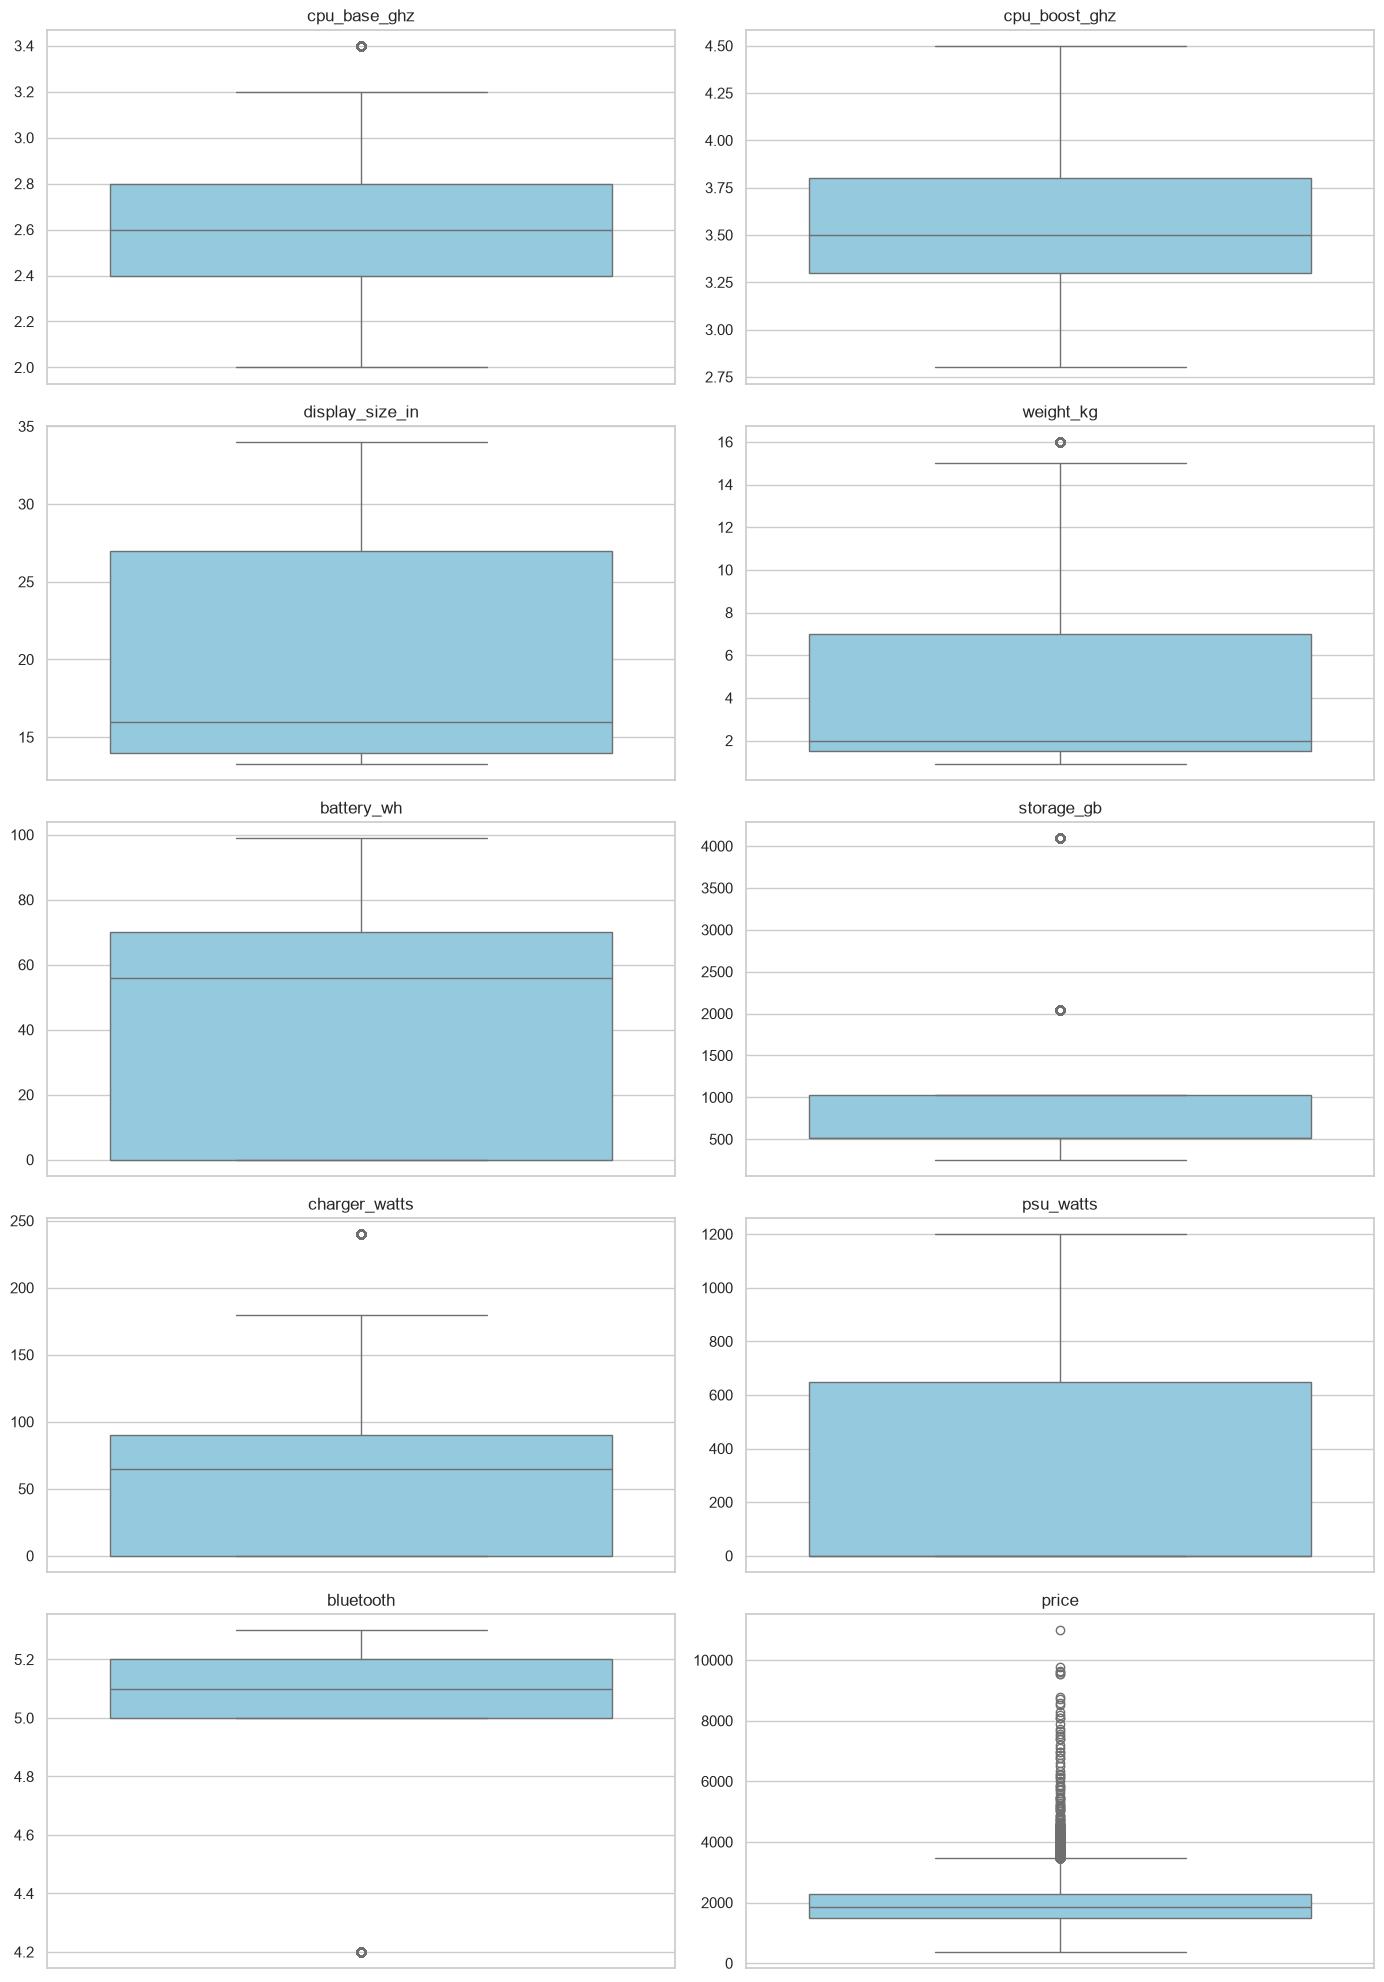

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

plt.figure(figsize=(14, n_rows * 4))

for i, col in enumerate(continuous_features):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        y=df_encoded[col],
        color="skyblue"
    )

    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [12]:
outlier_summary = []

for col in continuous_features:

    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_encoded[
        (df_encoded[col] < lower) |
        (df_encoded[col] > upper)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage (%)": round(len(outliers) / len(df_encoded) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Outliers,Percentage (%)
0,cpu_base_ghz,1978,1.98
1,cpu_boost_ghz,0,0.00
2,display_size_in,0,0.00
3,weight_kg,1031,1.03
4,battery_wh,0,0.00
5,storage_gb,14811,14.81
6,charger_watts,3039,3.04
7,psu_watts,0,0.00
8,bluetooth,5939,5.94
9,price,976,0.98


In [13]:
df_processed = df_encoded.copy()

for col in continuous_features:

    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_processed[col] = df_processed[col].clip(lower, upper)

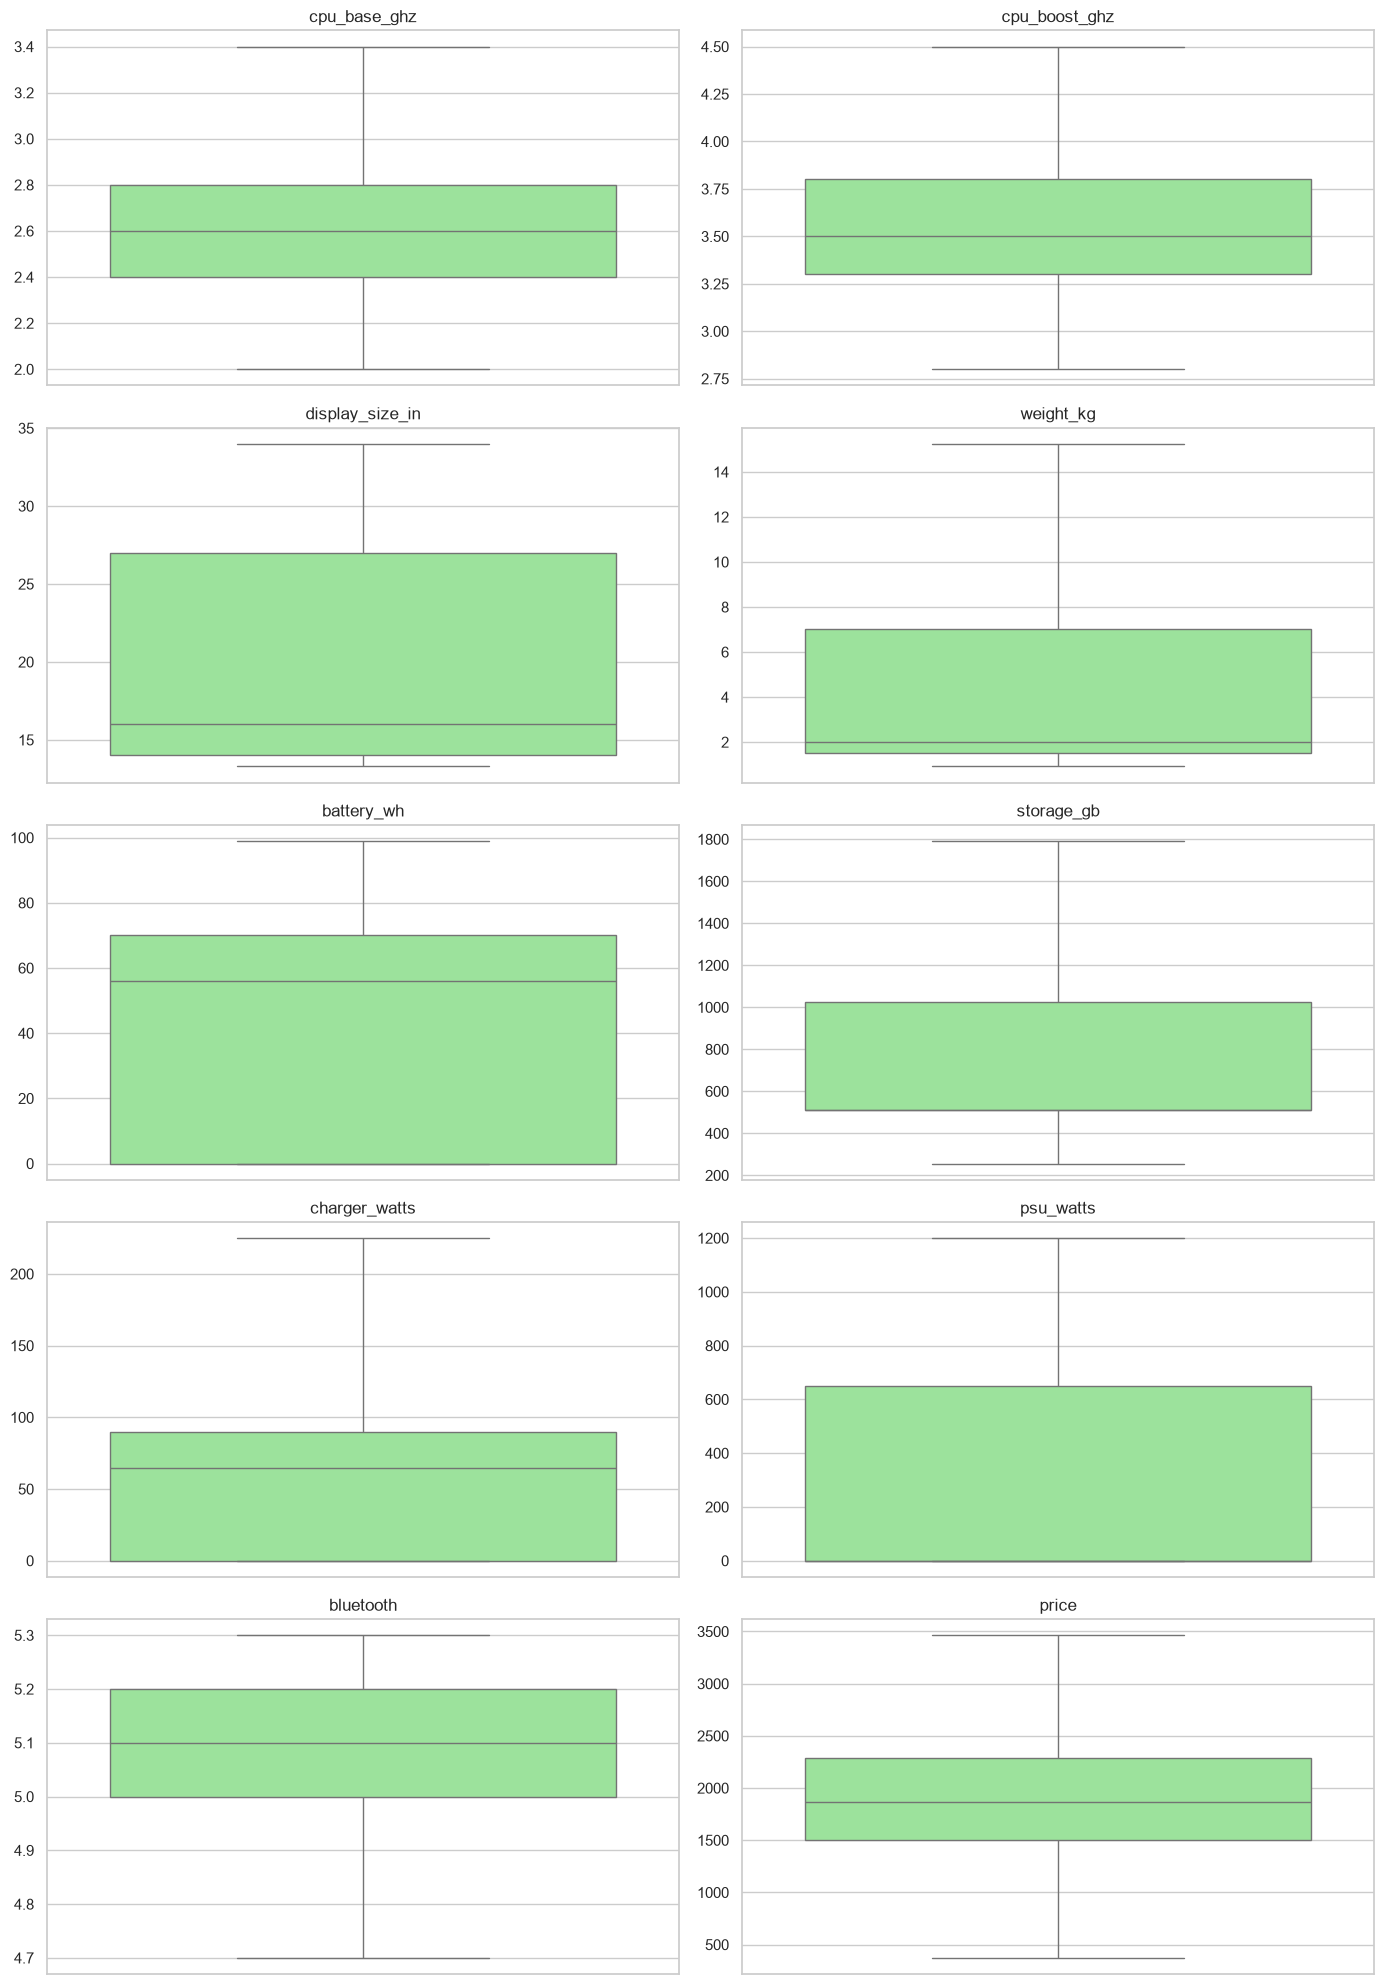

In [14]:
n_cols = 2
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

plt.figure(figsize=(14, n_rows * 4))

for i, col in enumerate(continuous_features):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        y=df_processed[col],
        color="lightgreen"
    )

    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

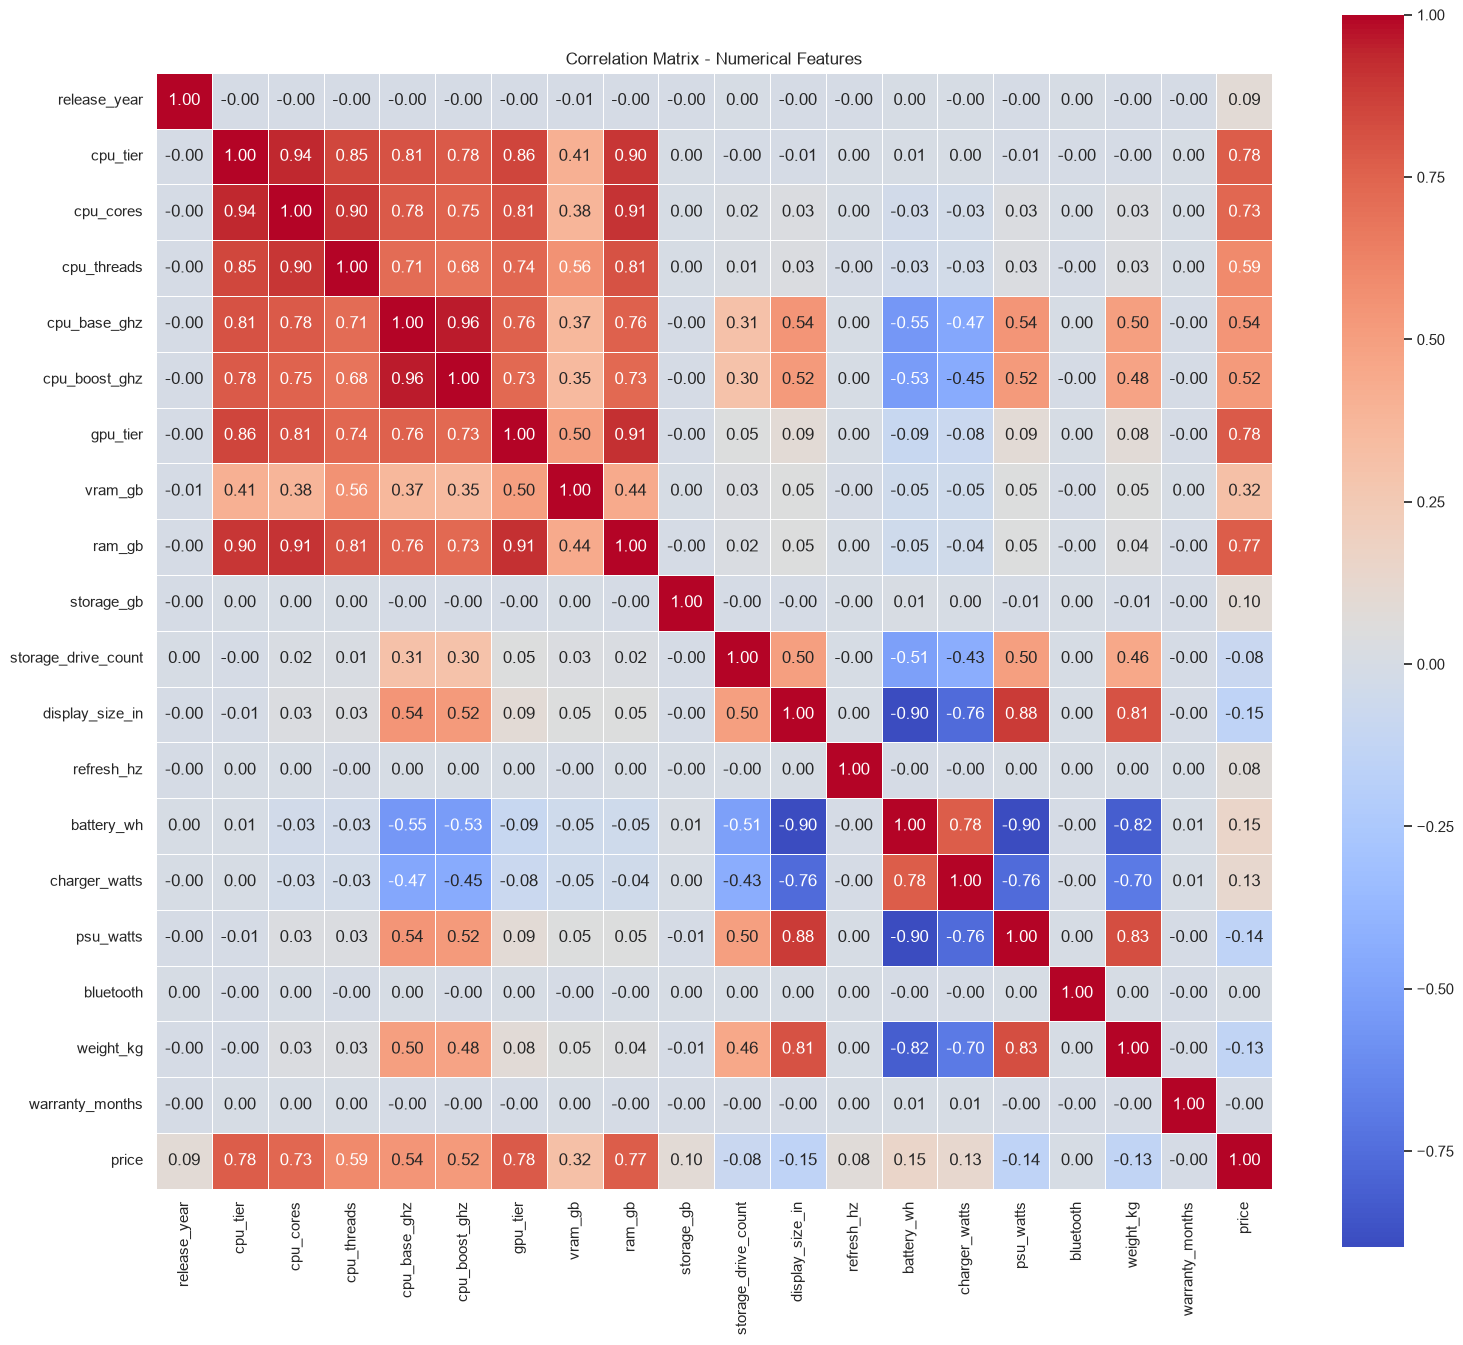

In [15]:
numerical_features = ["release_year","cpu_tier","cpu_cores","cpu_threads","cpu_base_ghz",
                      "cpu_boost_ghz","gpu_tier","vram_gb","ram_gb","storage_gb","storage_drive_count",
                      "display_size_in","refresh_hz","battery_wh","charger_watts","psu_watts",
                      "bluetooth","weight_kg","warranty_months"]

corr_numeric = df_processed[
    numerical_features + ["price"]
].corr()

plt.figure(figsize=(18,16))

sns.heatmap(
    corr_numeric,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    linecolor="white",
    square=True
)

plt.title("Correlation Matrix - Numerical Features")

plt.show()

In [16]:
corr_num = corr_numeric["price"].drop("price")

feature_rank_num = pd.DataFrame({
    "Feature": corr_num.index,
    "Correlation": corr_num.values,
    "AbsCorrelation": corr_num.abs().values
})

feature_rank_num = feature_rank_num.sort_values(
    by="AbsCorrelation",
    ascending=False
)

feature_rank_num

threshold = 0.50

chosen_numeric = feature_rank_num[
    feature_rank_num["AbsCorrelation"] >= threshold
]["Feature"].tolist()

print(chosen_numeric)

['gpu_tier', 'cpu_tier', 'ram_gb', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz']


In [17]:
corr_cat = df_encoded[
    related_cols + encoded_df.columns.tolist() + ["price"]
].corr()

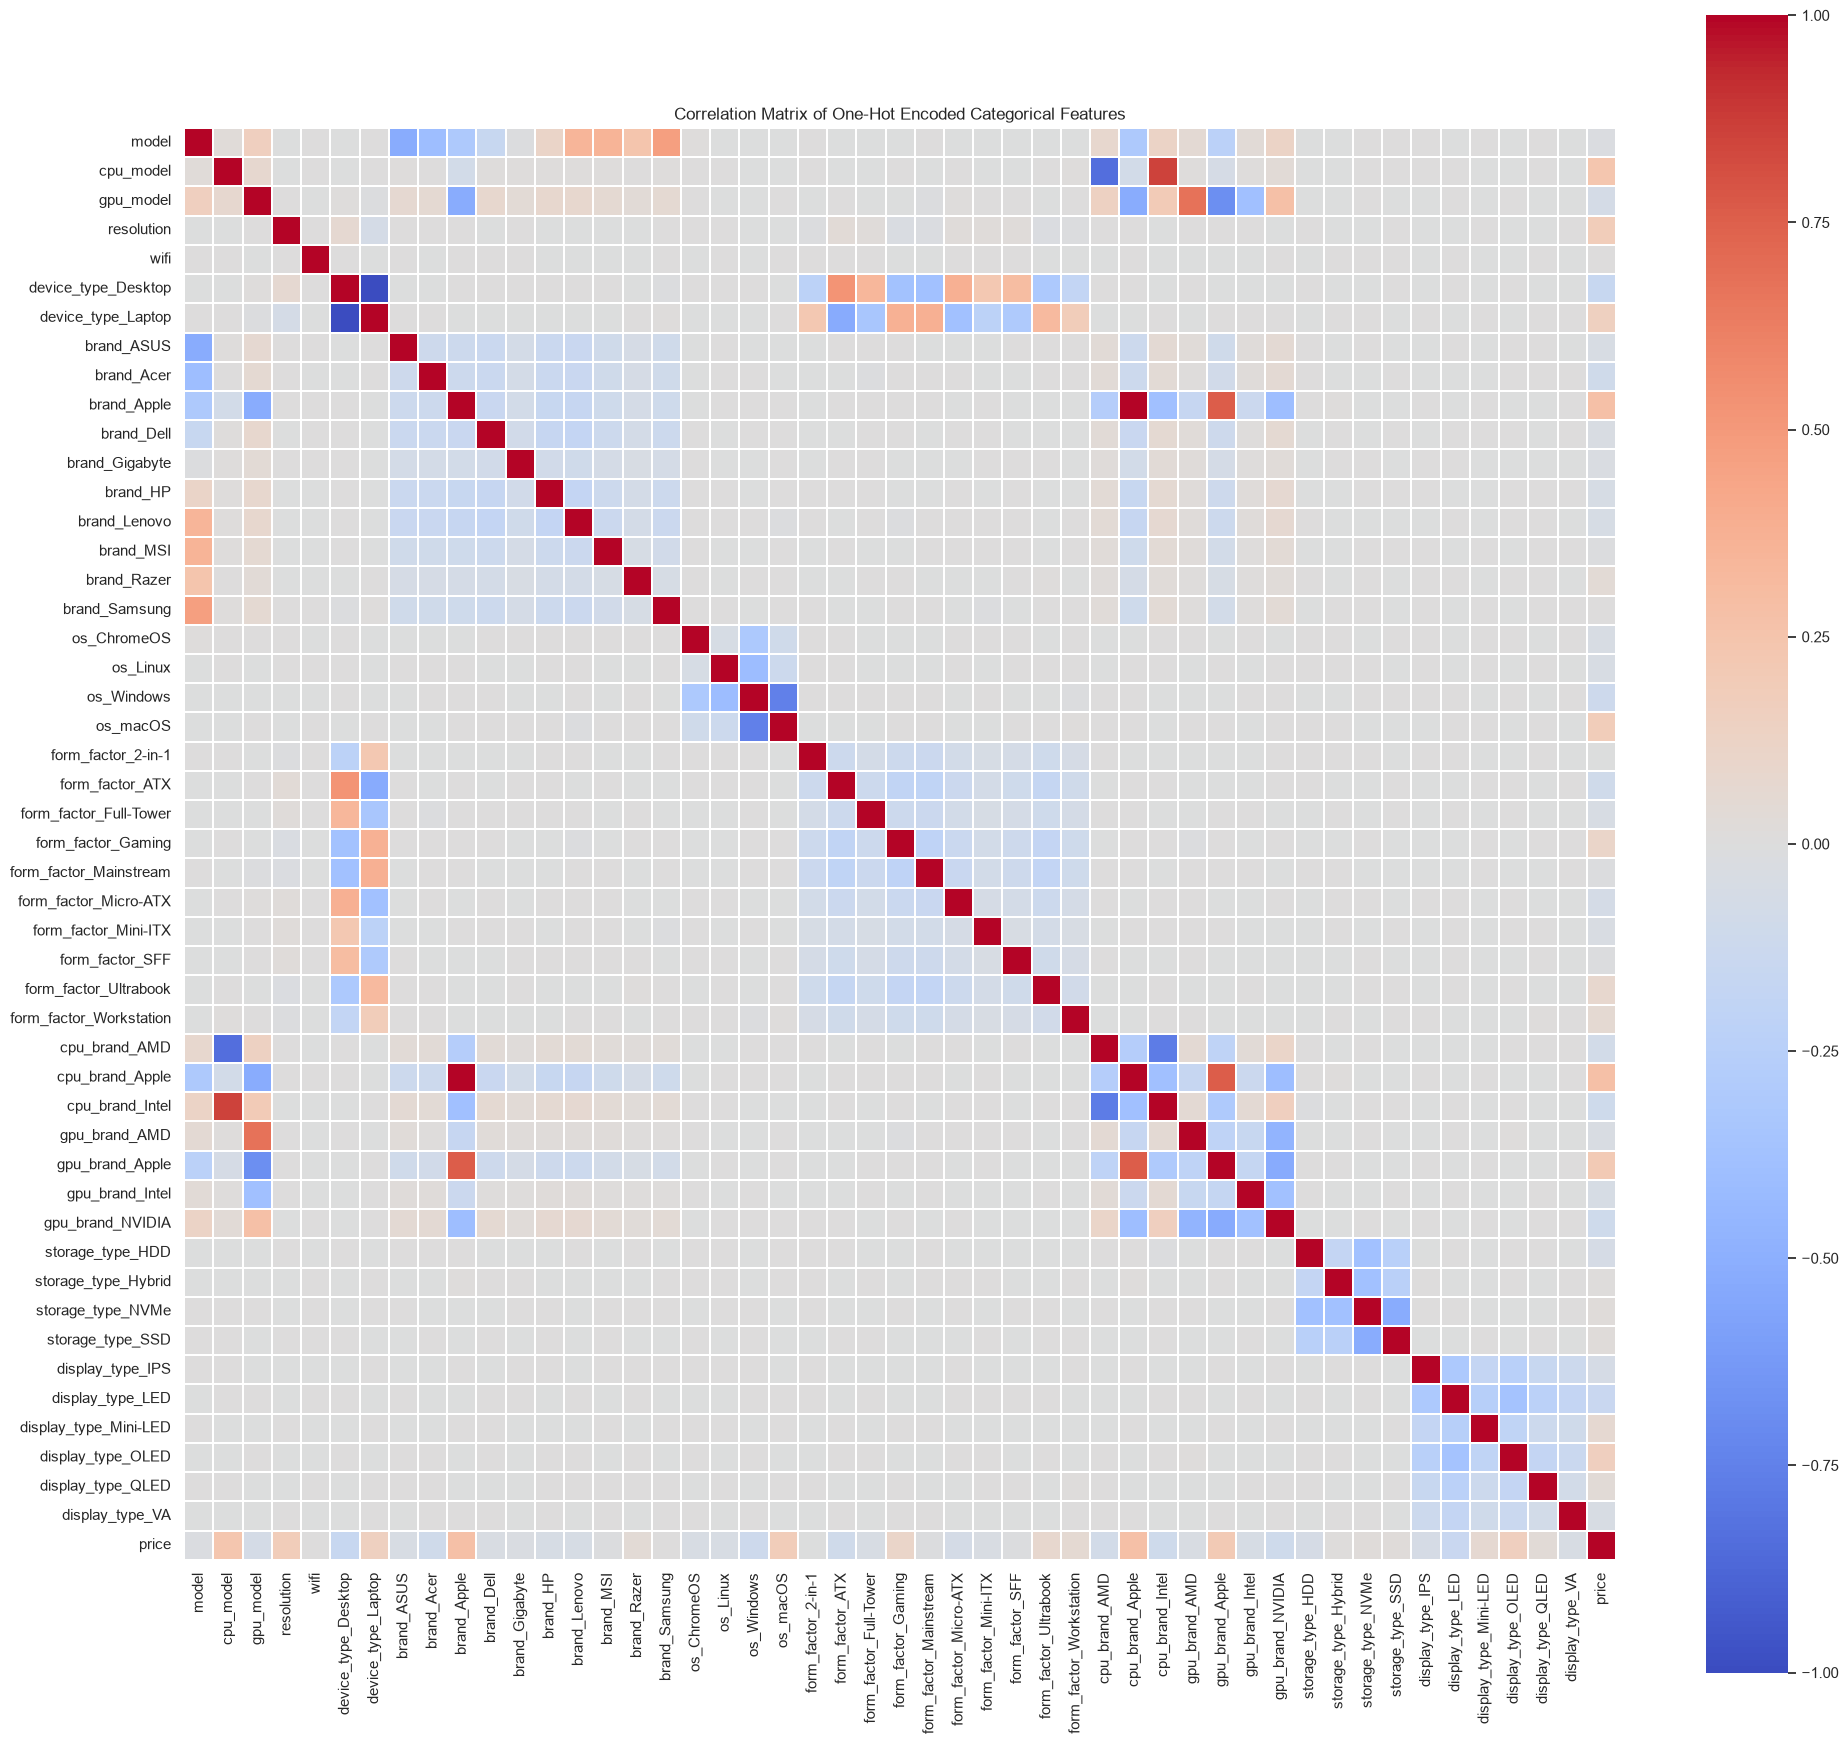

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 18))

sns.heatmap(
    corr_cat,
    cmap="coolwarm",
    annot=False,
    square=True,
    linewidths=0.1
)

plt.title("Correlation Matrix of One-Hot Encoded Categorical Features")
plt.tight_layout()
plt.show()

In [19]:
corr_price_cat = corr_cat["price"].drop("price")

feature_rank_cat = pd.DataFrame({
    "Feature": corr_price_cat.index,
    "Correlation": corr_price_cat.values,
    "AbsCorrelation": corr_price_cat.abs().values
})

feature_rank_cat = feature_rank_cat.sort_values(
    by="AbsCorrelation",
    ascending=False
).reset_index(drop=True)

display(feature_rank_cat)

,Feature,Correlation,AbsCorrelation
0,brand_Apple,0.274677,0.274677
1,cpu_brand_Apple,0.274677,0.274677
2,cpu_model,0.239347,0.239347
3,gpu_brand_Apple,0.204355,0.204355
4,resolution,0.185888,0.185888
5,os_macOS,0.182621,0.182621
6,display_type_OLED,0.158494,0.158494
7,device_type_Laptop,0.154123,0.154123
8,device_type_Desktop,-0.154123,0.154123
9,display_type_LED,-0.141971,0.141971


In [20]:
threshold = 0.15

chosen_categorical = feature_rank_cat[
    feature_rank_cat["AbsCorrelation"] >= threshold
]["Feature"].tolist()

print("Chosen Categorical Features:")
print(chosen_categorical)

Chosen Categorical Features:
['brand_Apple', 'cpu_brand_Apple', 'cpu_model', 'gpu_brand_Apple', 'resolution', 'os_macOS', 'display_type_OLED', 'device_type_Laptop', 'device_type_Desktop']


In [21]:
chosen_feature = chosen_numeric + chosen_categorical
print (chosen_feature)

['gpu_tier', 'cpu_tier', 'ram_gb', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'brand_Apple', 'cpu_brand_Apple', 'cpu_model', 'gpu_brand_Apple', 'resolution', 'os_macOS', 'display_type_OLED', 'device_type_Laptop', 'device_type_Desktop']


In [22]:
#Loại bỏ đặc trưng có ảnh hưởng như nhau
import numpy as np

corr_num = df_processed[chosen_feature].corr().abs()

upper = corr_num.where(
    np.triu(np.ones(corr_num.shape), k=1).astype(bool)
)

to_drop = []

for col in upper.columns:

    high_corr = upper[col][upper[col] > 0.90]

    for row in high_corr.index:

        corr_col = abs(df_processed[col].corr(df_processed["price"]))
        corr_row = abs(df_processed[row].corr(df_processed["price"]))

        if corr_col >= corr_row:
            to_drop.append(row)
        else:
            to_drop.append(col)

to_drop = list(set(to_drop))

final_categorical = [
    f for f in chosen_feature
    if f not in to_drop
]

print("Dropped Features:")
print(to_drop)

print("\nFinal Features:")
print(final_categorical)

Dropped Features:
['ram_gb', 'cpu_cores', 'brand_Apple', 'cpu_boost_ghz', 'device_type_Laptop']

Final Features:
['gpu_tier', 'cpu_tier', 'cpu_threads', 'cpu_base_ghz', 'cpu_brand_Apple', 'cpu_model', 'gpu_brand_Apple', 'resolution', 'os_macOS', 'display_type_OLED', 'device_type_Desktop']


In [23]:
#Chia tập và chuẩn hóa dữ liệu
X = df_processed[final_categorical]
y = df_processed["price"]

In [24]:
from sklearn.preprocessing import StandardScaler

#Columns to scale
scale_cols = ['gpu_tier', 'cpu_tier', 'cpu_threads', 'cpu_base_ghz', 'cpu_model', 'resolution']

#One-hot encoded columns
onehot_cols = ['cpu_brand_Apple', 'gpu_brand_Apple', 'os_macOS', 'display_type_OLED', 'device_type_Desktop']

scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,y,
    test_size=0.2,random_state=42,shuffle=True
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 11)
(20000, 11)
(80000,)
(20000,)


In [26]:
#Huấn luyện mô hình
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

In [27]:
#LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

rf_model = random_search.best_estimator_
rf_pred = rf_model.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [29]:
#XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [30]:
#Chức năng đánh giá mô hình
def evaluate_model(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [31]:
results = []

results.append(evaluate_model("Linear Regression",y_test,lr_pred))

results.append(evaluate_model("Random Forest",y_test,rf_pred))

results.append(evaluate_model("XGBoost",y_test,xgb_pred))

In [32]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,model,MAE,MSE,RMSE,R2
0,XGBoost,179.089153,52904.965937,230.010795,0.832937
1,Random Forest,183.127362,54959.025294,234.433413,0.826451
2,Linear Regression,183.168165,54983.725414,234.486088,0.826373


In [33]:
predictions = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

In [34]:
best_model_name = results_df.iloc[0]["model"]

best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


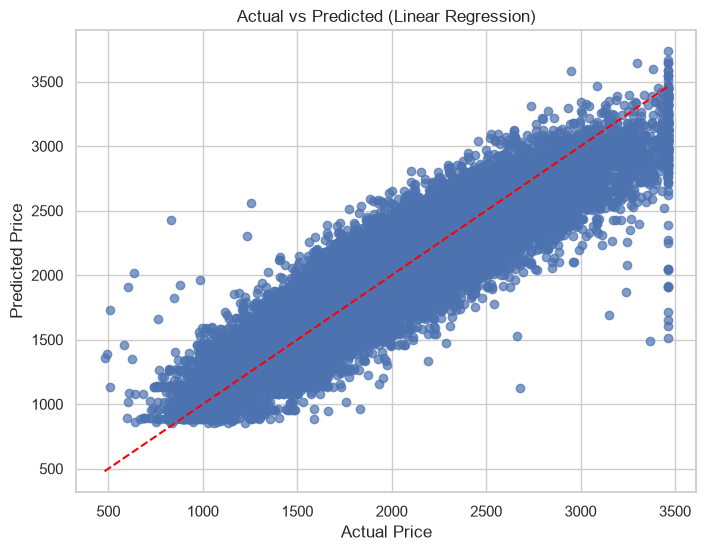

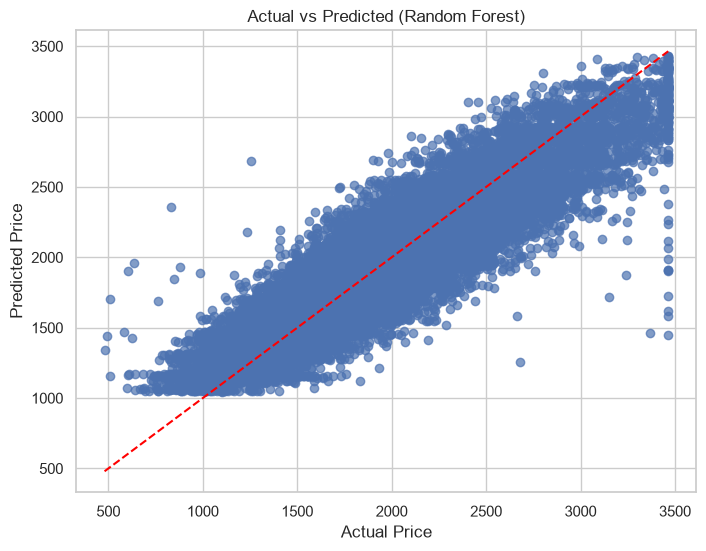

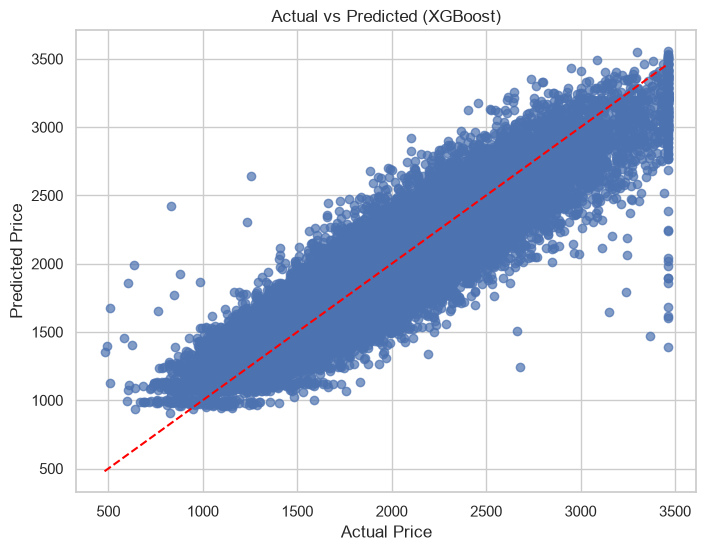

In [35]:
#Trực quan hóa kết quả dự báo của 3 mô hình
predictions = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for model_name, pred in predictions.items():

    plt.figure(figsize=(8,6))

    plt.scatter(
        y_test,
        pred,
        alpha=0.7
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )

    plt.xlabel("Actual Price")

    plt.ylabel("Predicted Price")

    plt.title(f"Actual vs Predicted ({model_name})")

    plt.grid(True)

    plt.show()

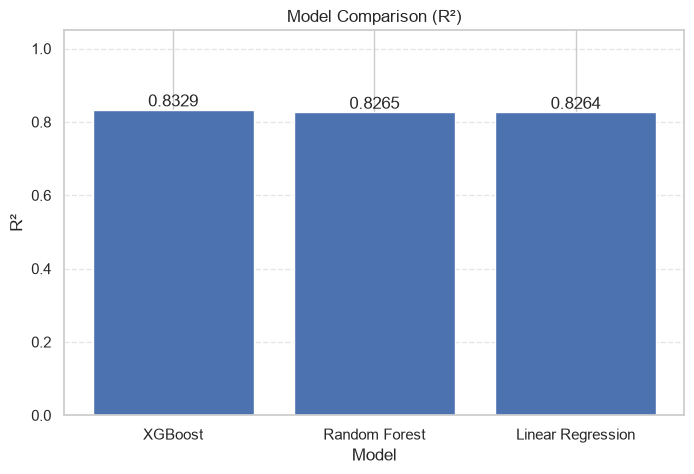

In [38]:
plt.figure(figsize=(8,5))

plt.bar(results_df["model"], results_df["R2"])

plt.title("Model Comparison (R²)")
plt.xlabel("Model")
plt.ylabel("R²")

for i, v in enumerate(results_df["R2"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [37]:
import pandas as pd
from sklearn.metrics import r2_score

models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred)
    })

r2_table = pd.DataFrame(results)

r2_table = r2_table.round(4)

print(r2_table)

               Model  Train R²  Test R²
0  Linear Regression    0.8226   0.8264
1      Random Forest    0.8300   0.8265
2            XGBoost    0.8398   0.8329
